# 💰 US Salary Prediction with Machine Learning

**A beginner-friendly walkthrough of predicting average annual salary (A_MEAN) across US states and occupations using the BLS OEWS dataset.**

### 📌 What this notebook covers
1. Loading & exploring the dataset
2. Exploratory Data Analysis (EDA)
3. **Data Leakage Detection** (very important step!)
4. Data cleaning & feature engineering
5. Train/test split
6. Model building — Random Forest vs XGBoost
7. Model evaluation (R², MAE, RMSE)
8. Feature importance
9. Conclusion

**Dataset**: US Bureau of Labor Statistics (BLS) Occupational Employment & Wage Statistics (OEWS), covering all 50 US states + territories, ~850 occupations, years 2022-2025.


## 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb

sns.set_style("whitegrid")
%matplotlib inline


## 2️⃣ Load & Explore the Data

In [2]:
df = pd.read_csv("salary_data_clean.csv")
print("Shape:", df.shape)
df.head()


Shape: (150262, 29)


,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_PCT25,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,year
0,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,13.48,18.50,28.94,43.25,21580.0,28030.0,38470.0,60190.0,89950.0,2022
1,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,31.83,46.12,63.53,86.89,47680.0,66210.0,95940.0,132150.0,180730.0,2022
2,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,52.15,65.83,90.64,NaN,50920.0,108470.0,136930.0,188530.0,NaN,2022
3,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1021,General and Operations Managers,...,31.39,47.17,71.64,105.19,44530.0,65280.0,98120.0,149010.0,218800.0,2022
4,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1031,Legislators,...,NaN,NaN,NaN,NaN,17080.0,18130.0,20320.0,35730.0,57060.0,2022


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150262 entries, 0 to 150261
Data columns (total 29 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   AREA          150262 non-null  int64  
 1   AREA_TITLE    150262 non-null  str    
 2   AREA_TYPE     150262 non-null  int64  
 3   PRIM_STATE    150262 non-null  str    
 4   NAICS         150262 non-null  int64  
 5   NAICS_TITLE   150262 non-null  str    
 6   I_GROUP       150262 non-null  str    
 7   OWN_CODE      150262 non-null  int64  
 8   OCC_CODE      150262 non-null  str    
 9   OCC_TITLE     150262 non-null  str    
 10  O_GROUP       150262 non-null  str    
 11  TOT_EMP       145883 non-null  float64
 12  EMP_PRSE      145883 non-null  float64
 13  JOBS_1000     145883 non-null  float64
 14  LOC_QUOTIENT  145883 non-null  float64
 15  H_MEAN        137592 non-null  float64
 16  A_MEAN        147425 non-null  float64
 17  MEAN_PRSE     148302 non-null  float64
 18  H_PCT10       1

In [4]:
# Missing values check
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)


H_PCT90         16005
H_PCT75         14630
H_MEDIAN        13823
H_PCT25         13025
H_MEAN          12670
H_PCT10         12621
A_PCT90          6447
A_PCT75          4869
TOT_EMP          4379
EMP_PRSE         4379
LOC_QUOTIENT     4379
JOBS_1000        4379
A_MEDIAN         4011
A_PCT25          3192
A_MEAN           2837
A_PCT10          2788
MEAN_PRSE        1960
dtype: int64

**Observation:** Several wage-related columns (hourly & annual percentiles) have missing values — this is normal in BLS data when sample sizes are small. Our target column is `A_MEAN` (annual mean wage).

## 3️⃣ Exploratory Data Analysis (EDA)

In [5]:
df['A_MEAN'].describe()


count    147425.000000
mean      70205.627268
std       43603.562777
min       17960.000000
25%       44500.000000
50%       58820.000000
75%       82450.000000
max      702270.000000
Name: A_MEAN, dtype: float64

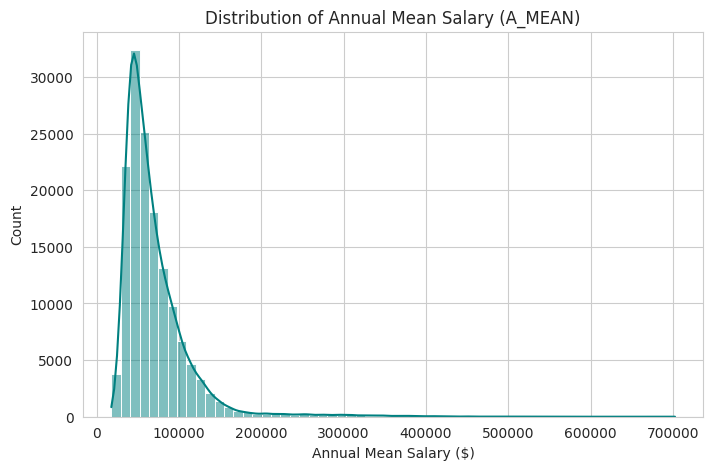

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['A_MEAN'].dropna(), bins=60, kde=True, color="teal")
plt.title("Distribution of Annual Mean Salary (A_MEAN)")
plt.xlabel("Annual Mean Salary ($)")
plt.show()


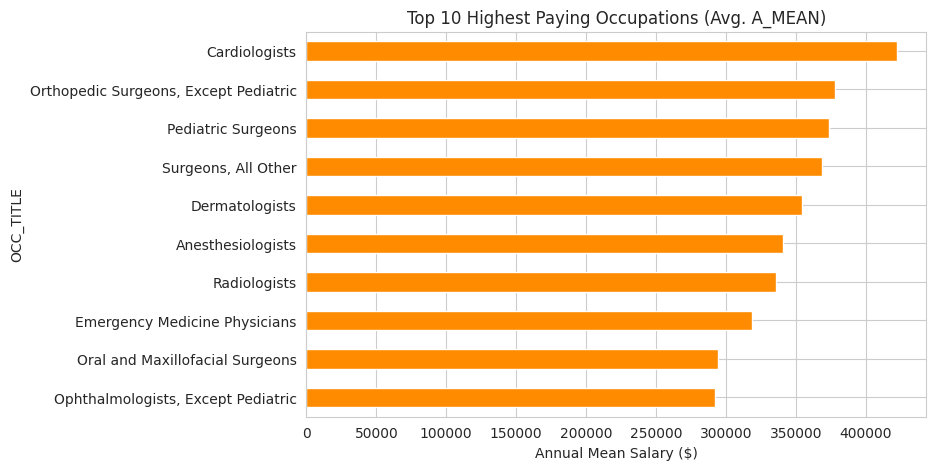

In [7]:
top_paying = (df[df['O_GROUP']=='detailed']
              .groupby('OCC_TITLE')['A_MEAN'].mean()
              .sort_values(ascending=False).head(10))

plt.figure(figsize=(8,5))
top_paying.plot(kind='barh', color="darkorange")
plt.title("Top 10 Highest Paying Occupations (Avg. A_MEAN)")
plt.xlabel("Annual Mean Salary ($)")
plt.gca().invert_yaxis()
plt.show()


## 4️⃣ ⚠️ Data Leakage Detection

Before building a model, it is critical to check for **data leakage** — columns that already contain information about the target and would make the model look artificially perfect.

In this dataset, the following columns are **directly derived from the same wage distribution** as our target `A_MEAN`, so they must be **dropped**:

| Leaky Column | Why it leaks |
|---|---|
| `H_MEAN` | Hourly mean — same value as A_MEAN, just a different unit (A_MEAN ≈ H_MEAN × 2080) |
| `H_PCT10, H_PCT25, H_MEDIAN, H_PCT75, H_PCT90` | Hourly wage percentiles of the same distribution |
| `A_PCT10, A_PCT25, A_MEDIAN, A_PCT75, A_PCT90` | Annual wage percentiles of the same distribution |
| `MEAN_PRSE` | Relative standard error of the mean wage — calculated *from* A_MEAN |

We also drop a few **constant/redundant columns** that carry no useful information:
- `NAICS`, `NAICS_TITLE`, `I_GROUP`, `OWN_CODE` → single constant value across the entire dataset (this file only covers "cross-industry" data)
- `PRIM_STATE`, `AREA_TITLE`, `OCC_TITLE` → text versions of columns we already have as numeric codes (`AREA`, `OCC_CODE`)


In [8]:
leak_cols = ['H_MEAN', 'MEAN_PRSE', 'H_PCT10', 'H_PCT25', 'H_MEDIAN', 'H_PCT75', 'H_PCT90',
             'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90']

redundant_cols = ['NAICS', 'NAICS_TITLE', 'I_GROUP', 'OWN_CODE',
                  'PRIM_STATE', 'AREA_TITLE', 'OCC_TITLE']

df_model = df.drop(columns=leak_cols + redundant_cols)
df_model = df_model.dropna(subset=['A_MEAN'])   # drop rows with no target value
print("Shape after cleanup:", df_model.shape)
df_model.head()


Shape after cleanup: (147425, 10)


,AREA,AREA_TYPE,OCC_CODE,O_GROUP,TOT_EMP,EMP_PRSE,JOBS_1000,LOC_QUOTIENT,A_MEAN,year
0,1,2,00-0000,total,2004000.0,0.0,1000.000,1.00,50620.0,2022
1,1,2,11-0000,major,104280.0,1.0,52.034,0.78,110500.0,2022
2,1,2,11-1011,detailed,710.0,13.4,0.355,0.26,190680.0,2022
3,1,2,11-1021,detailed,36550.0,2.7,18.239,0.80,120640.0,2022
4,1,2,11-1031,detailed,930.0,8.4,0.464,1.60,30000.0,2022


## 5️⃣ Feature Engineering

In [9]:
# Fill remaining missing numeric values with median
num_cols_to_fill = ['TOT_EMP', 'EMP_PRSE', 'JOBS_1000', 'LOC_QUOTIENT']
for col in num_cols_to_fill:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Encode categorical columns
le_occ = LabelEncoder()
df_model['OCC_CODE_ENC'] = le_occ.fit_transform(df_model['OCC_CODE'])

le_group = LabelEncoder()
df_model['O_GROUP_ENC'] = le_group.fit_transform(df_model['O_GROUP'])

features = ['AREA', 'AREA_TYPE', 'OCC_CODE_ENC', 'O_GROUP_ENC',
            'TOT_EMP', 'EMP_PRSE', 'JOBS_1000', 'LOC_QUOTIENT', 'year']
target = 'A_MEAN'

X = df_model[features]
y = df_model[target]
print("Features used:", features)


Features used: ['AREA', 'AREA_TYPE', 'OCC_CODE_ENC', 'O_GROUP_ENC', 'TOT_EMP', 'EMP_PRSE', 'JOBS_1000', 'LOC_QUOTIENT', 'year']


## 6️⃣ Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)


Train size: (117940, 9) | Test size: (29485, 9)


## 7️⃣ Model Building

### 🌳 Model 1: Random Forest Regressor

In [11]:
rf_model = RandomForestRegressor(
    n_estimators=300, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"Random Forest -> R2: {rf_r2:.4f} | MAE: {rf_mae:,.0f} | RMSE: {rf_rmse:,.0f}")


Random Forest -> R2: 0.9218 | MAE: 7,006 | RMSE: 12,196


### ⚡ Model 2: XGBoost Regressor

In [12]:
xgb_model = xgb.XGBRegressor(
    n_estimators=600, max_depth=10, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f"XGBoost -> R2: {xgb_r2:.4f} | MAE: {xgb_mae:,.0f} | RMSE: {xgb_rmse:,.0f}")


XGBoost -> R2: 0.8636 | MAE: 8,189 | RMSE: 16,108


## 8️⃣ Model Comparison

In [13]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "R2 Score": [rf_r2, xgb_r2],
    "MAE": [rf_mae, xgb_mae],
    "RMSE": [rf_rmse, xgb_rmse]
})
results


,Model,R2 Score,MAE,RMSE
0,Random Forest,0.921794,7006.253198,12196.031296
1,XGBoost,0.863571,8189.273024,16108.333010


/tmp/ipykernel_657/1260154324.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="R2 Score", palette="viridis")


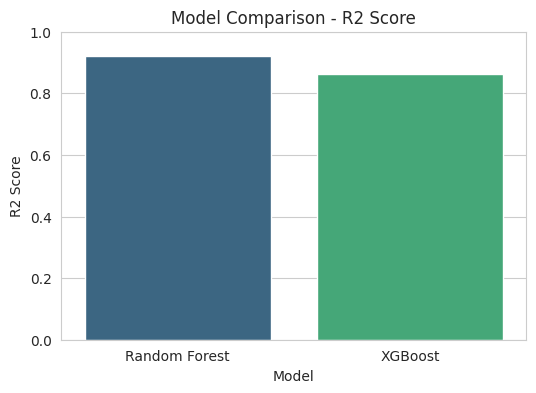

In [14]:
plt.figure(figsize=(6,4))
sns.barplot(data=results, x="Model", y="R2 Score", palette="viridis")
plt.title("Model Comparison - R2 Score")
plt.ylim(0, 1)
plt.show()


## 9️⃣ Feature Importance (Best Model — Random Forest)

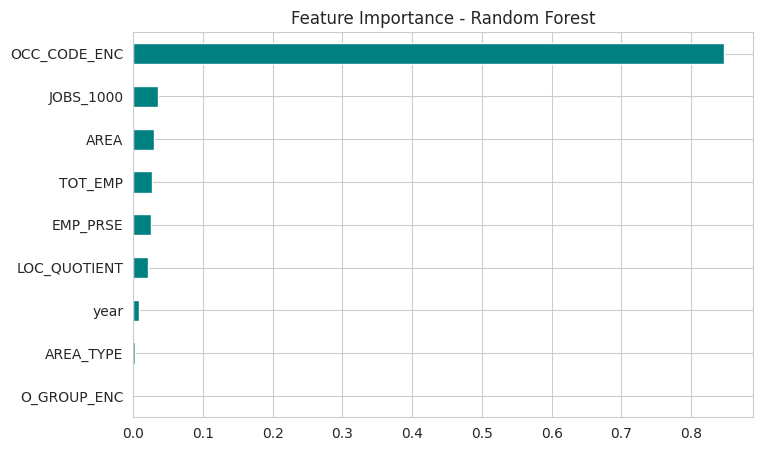

OCC_CODE_ENC    0.846496
JOBS_1000       0.035648
AREA            0.030499
TOT_EMP         0.027158
EMP_PRSE        0.026273
LOC_QUOTIENT    0.021270
year            0.009057
AREA_TYPE       0.003068
O_GROUP_ENC     0.000532
dtype: float64

In [15]:
importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind='barh', color="teal")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

importance


## 🔟 Conclusion

- We predicted **annual mean salary (A_MEAN)** across US states and occupations using the BLS OEWS dataset.
- A **thorough data leakage check** was the most important step — several wage-percentile columns had to be removed because they were mathematically derived from the same salary distribution as our target.
- After cleaning, we used 9 legitimate features: location, occupation code, occupation group level, employment counts, and time.
- **Random Forest was the best performing model (R² ≈ 0.92)**, clearly beating XGBoost (R² ≈ 0.86) on this dataset. This is because the occupation code — a high-cardinality categorical feature — is captured very effectively by Random Forest's tree splits, which was also confirmed as the single most important feature (~85% importance).
- **Key takeaway:** the *occupation* itself is by far the strongest driver of salary, followed by employment concentration (`JOBS_1000`) and location quotient — while the specific US state and year play a smaller role.
- **Future improvements**: target-encoding the occupation code, adding regional cost-of-living data, or trying gradient boosting with categorical-native support (e.g., CatBoost) could push accuracy even higher.
